In [ ]:
# ON HPC

#library(arrow)
library(ggplot2)
#library(qvalue)
library(vroom)
library(dplyr)

# CT Results
# Summary of leads: 
#   - paste0(indir,cell.type,'.qvalue.cis_qtl.txt.gz') 
#   - ex: /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/tensorQTL/07_H3K27me3QTLs/outs/Endothelial.qvalue.cis_qtl.txt.gz
# Full summary stats: 
#   - paste0(outdir, cell.type, '.cis_qtl_pairs.chr.qvalue.tsv')
#   - ex: /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/tensorQTL/07_H3K27me3QTLs/outs/Endothelial.cis_qtl_pairs.chr.qvalue.tsv
# Significant summary stats: 
#   - paste0(outdir, cell.type, '.cis_qtl_pairs.chr.qvalue.sig.tsv')
#   - ex: /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/tensorQTL/07_H3K27me3QTLs/outs/Endothelial.cis_qtl_pairs.chr.qvalue.sig.tsv

indir <- '/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/tensorQTL/07_H3K27me3QTLs/outs/'
outdir <- '/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/tensorQTL/07_H3K27me3QTLs/outs/'
unique_cell_types <- c('Endothelial', 'Hepatocytes', 'T', 'HSC', 'Cholangiocyte', 'Myeloid', 'NK', 'B', 'Bulk')

summary.df <- NULL

for (cell.type in unique_cell_types) {
    message(paste0("Start of ", cell.type," - ", Sys.time()))
    leads <- vroom(paste0(indir,cell.type,'.qvalue.cis_qtl.txt.gz'), show_col_types=FALSE)
    message(paste0("Number of QTL.Features for ", cell.type,": ", sum(leads$qval < 0.05)))
    
    ct.res <- data.frame()
    for (i in 1:22) {
        message(paste0(cell.type," chr",i," - ", Sys.time()))
        chr.res <- vroom(paste0(indir,'tsv.test/',cell.type,'.cis_qtl_pairs.chr',i,'.parquet.tsv'), show_col_types=FALSE)
        chr.res$sig.qtl <- FALSE
        
        if ('pval_nominal_threshold' %in% colnames(leads)) {
            chr.res <- left_join(chr.res, select(leads, phenotype_id, pval_nominal_threshold), join_by(phenotype_id))
            chr.res$sig.qtl <- chr.res$pval_nominal < chr.res$pval_nominal_threshold
        }
        
        message(paste0("Comparisons for ", cell.type, ' chr',i,": ", nrow(chr.res)))
        message(paste0("Significant comparisons for ", cell.type, ' chr',i,": ", sum(chr.res$sig.qtl)))
        
        ct.res <- rbind(ct.res, chr.res)
        gc()
    }
    
    write.table(ct.res, paste0(outdir, cell.type, '.cis_qtl_pairs.chr.qvalue.tsv'),
           sep='\t', col.names=T, row.names=F, quote=F)
    write.table(filter(ct.res, sig.qtl), paste0(outdir, cell.type, '.cis_qtl_pairs.chr.qvalue.sig.tsv'),
               sep='\t', col.names=T, row.names=F, quote=F)
    
    message(paste0("End of ", cell.type," - ", Sys.time()))
    message(paste0("Comparisons for ", cell.type, ": ", nrow(ct.res)))
    message(paste0("Significant comparisons for ", cell.type, ": ", sum(ct.res$sig.qtl)))
    
    summary.df <- rbind(summary.df, data.frame(cell=cell.type, features=nrow(leads), features.sig=sum(leads$qval < 0.05),
                          tests=nrow(ct.res), tests.sig=sum(ct.res$sig.qtl)))
    
    ct.res <- NULL
    leads <- NULL
    gc()
}
summary.df

write.table(summary.df, paste0(outdir, 'H3K27me3QTL.summary.tsv'),
           quote=F, row.names=F, col.names=T, sep='\t')

In [6]:
library(ggplot2)
library(dplyr)

Warning message:
“package ‘dplyr’ was built under R version 4.3.2”

Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [2]:
summary.df <- read.table('/nfs/lab/tscc/welison/FNIH.Liver/tensorQTL/07_H3K27me3QTLs/outs/H3K27me3QTL.summary.tsv', header=T)
summary.df

cell,features,features.sig,tests,tests.sig
<chr>,<int>,<int>,<int>,<int>
Endothelial,115961,0,473405994,0
Hepatocytes,425751,388,1780298783,31798
T,14066,0,54571947,0
HSC,21015,0,82813105,0
Cholangiocyte,87146,1,357665323,54
Myeloid,268394,2,1099830089,101
NK,2632,0,9940030,0
B,1240,0,4652675,0
Bulk,455078,356,1897044825,36142


In [4]:
celltype_colors <- c(
  NK = "#6A0DAD",          
  T = "#9B59B6",           
  Endothelial = "#CF1B14", 
  Myeloid = "#E8773B",     
  B = "#E995E7",           
  Cholangiocyte = "#E1AD01",
  HSC = "#4682B4",         
  Mast = "#FD7BB8",        
  Schwann = "#81CDC6",     
  Hepatocytes = "#4DAF4A"  
)

In [5]:
summary.df <- arrange(summary.df, features)
summary.df$cell <- factor(summary.df$cell, levels=summary.df$cell)

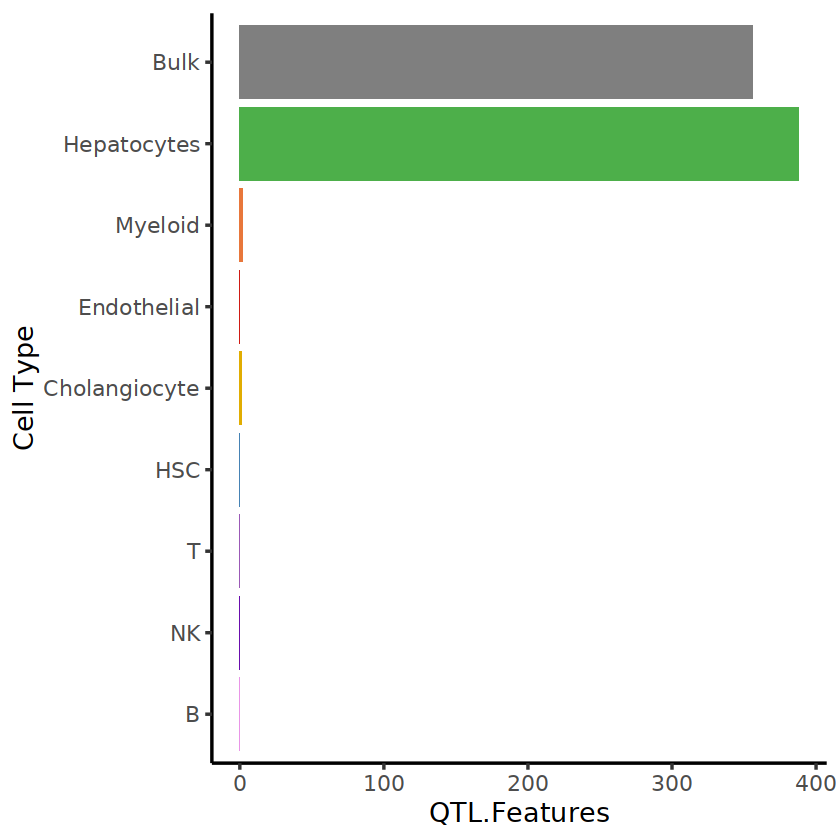

In [6]:
ggplot(summary.df, aes(y=cell, x=features.sig, fill=cell)) + geom_col() + 
    scale_fill_manual(values=celltype_colors) + theme_classic(base_size=16) + 
    labs(fill='Cell Type', x='QTL.Features', y='Cell Type') + theme(legend.position="none")

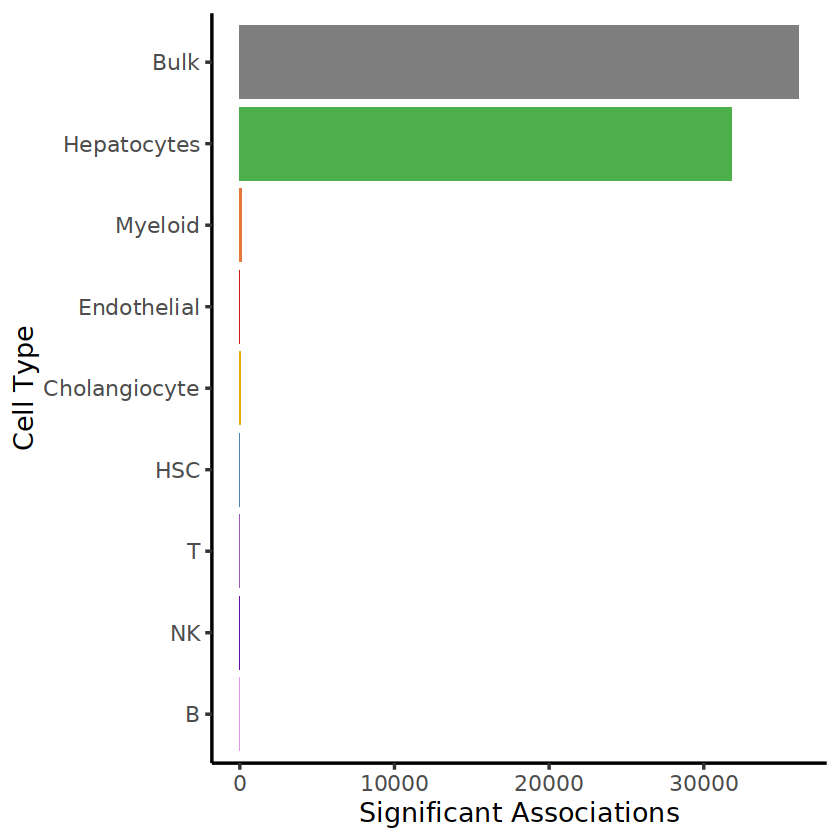

In [9]:
ggplot(summary.df, aes(y=cell, x=tests.sig, fill=cell)) + geom_col() + 
    scale_fill_manual(values=celltype_colors) + theme_classic(base_size=16) + 
    labs(fill='Cell Type', x='Significant Associations', y='Cell Type') + theme(legend.position="none")

# TMM

In [ ]:
srun --pty --nodes=1 --ntasks-per-node=1 --cpus-per-task=4 --mem=320G --account=csd854 -t 48:00:00 -p condo -q condo --wait 0 /bin/bash
conda activate a100.tensorQTL
for parq in *.parquet; do parquet-tools csv $parq | sed 's|,|\t|g' > $parq.tsv; done

In [ ]:
# ON HPC
srun --pty --nodes=1 --ntasks-per-node=1 --cpus-per-task=4 --mem=320G --account=csd854 -t 48:00:00 -p condo -q condo --wait 0 /bin/bash

#library(arrow)
library(ggplot2)
#library(qvalue)
library(vroom)
library(dplyr)

# CT Results
# Summary of leads: 
#   - paste0(indir,cell.type,'.cis_qtl.txt.gz') 
#   - ex: /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/tensorQTL/07_H3K27me3QTLs/tmm.outs/Endothelial.cis_qtl.txt.gz
# Full summary stats: 
#   - paste0(outdir, cell.type, '.cis_qtl_pairs.chr.tsv')
#   - ex: /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/tensorQTL/07_H3K27me3QTLs/tmm.outs/Endothelial.cis_qtl_pairs.chr.tsv
# Significant summary stats: 
#   - paste0(outdir, cell.type, '.cis_qtl_pairs.chr.sig.tsv')
#   - ex: /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/tensorQTL/07_H3K27me3QTLs/tmm.outs/Endothelial.cis_qtl_pairs.chr.sig.tsv

indir <- '/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/tensorQTL/07_H3K27me3QTLs/tmm.outs/'
outdir <- '/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/tensorQTL/07_H3K27me3QTLs/tmm.outs/'
unique_cell_types <- c('Endothelial', 'Hepatocytes', 'T', 'HSC', 'Cholangiocyte', 'Myeloid', 'NK', 'B', 'Bulk')

summary.df <- NULL

for (cell.type in unique_cell_types) {
    message(paste0("Start of ", cell.type," - ", Sys.time()))
    leads <- vroom(paste0(indir,cell.type,'.cis_qtl.txt.gz'), show_col_types=FALSE)
    message(paste0("Number of QTL.Features for ", cell.type,": ", sum(leads$qval < 0.05)))
    
    ct.res <- data.frame()
    for (i in 1:22) {
        message(paste0(cell.type," chr",i," - ", Sys.time()))
        chr.res <- vroom(paste0(indir,'',cell.type,'.cis_qtl_pairs.chr',i,'.parquet.tsv'), show_col_types=FALSE)
        chr.res$sig.qtl <- FALSE
        
        if ('pval_nominal_threshold' %in% colnames(leads)) {
            chr.res <- left_join(chr.res, select(leads, phenotype_id, pval_nominal_threshold), join_by(phenotype_id))
            chr.res$sig.qtl <- chr.res$pval_nominal < chr.res$pval_nominal_threshold
        }
        
        message(paste0("Comparisons for ", cell.type, ' chr',i,": ", nrow(chr.res)))
        message(paste0("Significant comparisons for ", cell.type, ' chr',i,": ", sum(chr.res$sig.qtl)))
        
        ct.res <- rbind(ct.res, chr.res)
        gc()
    }
    
    write.table(ct.res, paste0(outdir, cell.type, '.cis_qtl_pairs.chr.tsv'),
           sep='\t', col.names=T, row.names=F, quote=F)
    write.table(filter(ct.res, sig.qtl), paste0(outdir, cell.type, '.cis_qtl_pairs.chr.sig.tsv'),
               sep='\t', col.names=T, row.names=F, quote=F)
    
    message(paste0("End of ", cell.type," - ", Sys.time()))
    message(paste0("Comparisons for ", cell.type, ": ", nrow(ct.res)))
    message(paste0("Significant comparisons for ", cell.type, ": ", sum(ct.res$sig.qtl)))
    
    summary.df <- rbind(summary.df, data.frame(cell=cell.type, features=nrow(leads), features.sig=sum(leads$qval < 0.05),
                          tests=nrow(ct.res), tests.sig=sum(ct.res$sig.qtl)))
    
    ct.res <- NULL
    leads <- NULL
    gc()
}
summary.df

write.table(summary.df, paste0(outdir, 'H3K27me3QTL.summary.tsv'),
           quote=F, row.names=F, col.names=T, sep='\t')

In [3]:
library(ggplot2)
library(dplyr)

In [2]:
summary.df <- read.table('/nfs/lab/tscc/welison/FNIH.Liver/tensorQTL/07_H3K27me3QTLs/tmm.outs/H3K27me3QTL.summary.tsv', header=T)
summary.df

cell,features,features.sig,tests,tests.sig
<chr>,<int>,<int>,<int>,<int>
Endothelial,115961,0,473405994,0
Hepatocytes,425751,388,1780298783,31798
T,14066,0,54571947,0
HSC,21015,0,82813105,0
Cholangiocyte,87146,1,357665323,54
Myeloid,268394,2,1099830089,101
NK,2632,0,9940030,0
B,1240,0,4652675,0
Bulk,455078,356,1897044825,36142


In [4]:
celltype_colors <- c(
  NK = "#6A0DAD",          
  T = "#9B59B6",           
  Endothelial = "#CF1B14", 
  Myeloid = "#E8773B",     
  B = "#E995E7",           
  Cholangiocyte = "#E1AD01",
  HSC = "#4682B4",         
  Mast = "#FD7BB8",        
  Schwann = "#81CDC6",     
  Hepatocytes = "#4DAF4A"  
)

In [5]:
summary.df <- arrange(summary.df, features)
summary.df$cell <- factor(summary.df$cell, levels=summary.df$cell)

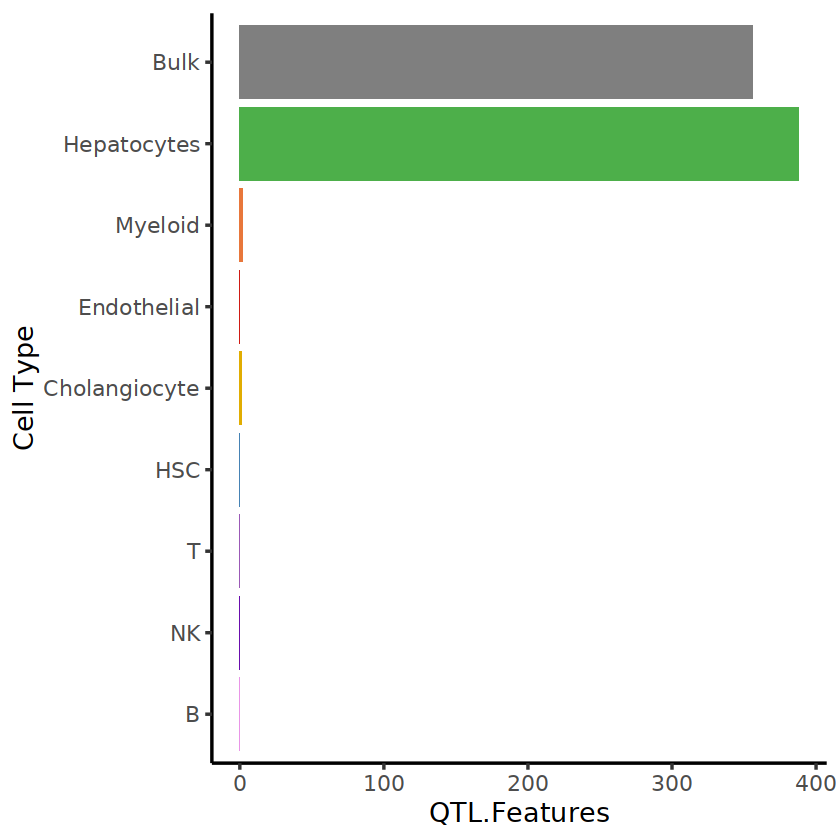

In [6]:
ggplot(summary.df, aes(y=cell, x=features.sig, fill=cell)) + geom_col() + 
    scale_fill_manual(values=celltype_colors) + theme_classic(base_size=16) + 
    labs(fill='Cell Type', x='QTL.Features', y='Cell Type') + theme(legend.position="none")

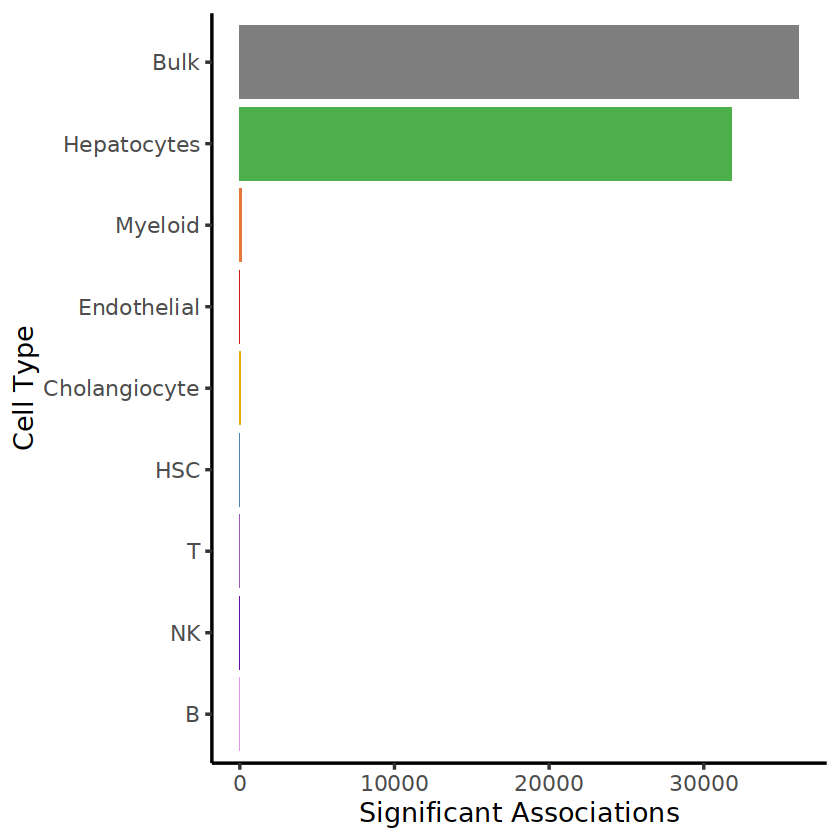

In [9]:
ggplot(summary.df, aes(y=cell, x=tests.sig, fill=cell)) + geom_col() + 
    scale_fill_manual(values=celltype_colors) + theme_classic(base_size=16) + 
    labs(fill='Cell Type', x='Significant Associations', y='Cell Type') + theme(legend.position="none")

# TSS

In [ ]:
srun --pty --nodes=1 --ntasks-per-node=1 --cpus-per-task=4 --mem=320G --account=csd854 -t 48:00:00 -p condo -q condo --wait 0 /bin/bash
conda activate a100.tensorQTL
for parq in *.parquet; do parquet-tools csv $parq | sed 's|,|\t|g' > $parq.tsv; done

In [3]:
file.exists()

ERROR: Error in file.exists(): invalid 'file' argument


In [ ]:
# ON HPC
#srun --pty --nodes=1 --ntasks-per-node=1 --cpus-per-task=4 --mem=320G --account=csd854 -t 48:00:00 -p condo -q condo --wait 0 /bin/bash

#library(arrow)
library(ggplot2)
#library(qvalue)
library(vroom)
library(dplyr)

# CT Results
# Summary of leads: 
#   - paste0(indir,cell.type,'.cis_qtl.txt.gz') 
#   - ex: /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/tensorQTL/07_H3K27me3QTLs/TSS/outs/Endothelial.cis_qtl.txt.gz
# Full summary stats: 
#   - paste0(outdir, cell.type, '.cis_qtl_pairs.chr.tsv')
#   - ex: /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/tensorQTL/07_H3K27me3QTLs/TSS/outs/Endothelial.cis_qtl_pairs.chr.tsv
# Significant summary stats: 
#   - paste0(outdir, cell.type, '.cis_qtl_pairs.chr.sig.tsv')
#   - ex: /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/tensorQTL/07_H3K27me3QTLs/TSS/outs/Endothelial.cis_qtl_pairs.chr.sig.tsv

indir <- '/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/tensorQTL/07_H3K27me3QTLs/TSS/outs/'
outdir <- '/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/tensorQTL/07_H3K27me3QTLs/TSS/outs/'
unique_cell_types <- c('Endothelial', 'Hepatocytes', 'HSC', 'Cholangiocyte', 'Myeloid')

summary.df <- NULL

for (cell.type in unique_cell_types) {
    message(paste0("Start of ", cell.type," - ", Sys.time()))
    leads <- vroom(paste0(indir,cell.type,'.cis_qtl.txt.gz'), show_col_types=FALSE)
    message(paste0("Number of QTL.Features for ", cell.type,": ", sum(leads$qval < 0.05)))
    
    ct.res <- data.frame()
    for (i in 1:22) {
        message(paste0(cell.type," chr",i," - ", Sys.time()))
        if (!file.exists(paste0(indir,'',cell.type,'.cis_qtl_pairs.chr',i,'.parquet.tsv'))) {
            next
        }
        chr.res <- vroom(paste0(indir,'',cell.type,'.cis_qtl_pairs.chr',i,'.parquet.tsv'), show_col_types=FALSE)
        chr.res$sig.qtl <- FALSE
        
        if ('pval_nominal_threshold' %in% colnames(leads)) {
            chr.res <- left_join(chr.res, select(leads, phenotype_id, pval_nominal_threshold), join_by(phenotype_id))
            chr.res$sig.qtl <- chr.res$pval_nominal < chr.res$pval_nominal_threshold
        }
        
        message(paste0("Comparisons for ", cell.type, ' chr',i,": ", nrow(chr.res)))
        message(paste0("Significant comparisons for ", cell.type, ' chr',i,": ", sum(chr.res$sig.qtl)))
        
        ct.res <- rbind(ct.res, chr.res)
        gc()
    }
    
    write.table(ct.res, paste0(outdir, cell.type, '.cis_qtl_pairs.chr.tsv'),
           sep='\t', col.names=T, row.names=F, quote=F)
    write.table(filter(ct.res, sig.qtl), paste0(outdir, cell.type, '.cis_qtl_pairs.chr.sig.tsv'),
               sep='\t', col.names=T, row.names=F, quote=F)
    
    message(paste0("End of ", cell.type," - ", Sys.time()))
    message(paste0("Comparisons for ", cell.type, ": ", nrow(ct.res)))
    message(paste0("Significant comparisons for ", cell.type, ": ", sum(ct.res$sig.qtl)))
    
    summary.df <- rbind(summary.df, data.frame(cell=cell.type, features=nrow(leads), features.sig=sum(leads$qval < 0.05),
                          tests=nrow(ct.res), tests.sig=sum(ct.res$sig.qtl)))
    
    ct.res <- NULL
    leads <- NULL
    gc()
}
summary.df

write.table(summary.df, paste0(outdir, 'H3K27me3QTL.summary.tsv'),
           quote=F, row.names=F, col.names=T, sep='\t')

In [3]:
library(ggplot2)
library(dplyr)

In [20]:
summary.df <- read.table('/nfs/lab/tscc/welison/FNIH.Liver/tensorQTL/07_H3K27me3QTLs/TSS/outs/H3K27me3QTL.summary.tsv', header=T)
summary.df

cell,features,features.sig,tests,tests.sig
<chr>,<int>,<int>,<int>,<int>
Endothelial,2519,0,9726822,0
Hepatocytes,23287,26,92705307,1619
HSC,21,0,65464,0
Cholangiocyte,1423,0,5556133,0
Myeloid,6770,0,26190518,0


In [21]:
celltype_colors <- c(
  NK = "#6A0DAD",          
  T = "#9B59B6",           
  Endothelial = "#CF1B14", 
  Myeloid = "#E8773B",     
  B = "#E995E7",           
  Cholangiocyte = "#E1AD01",
  HSC = "#4682B4",         
  Mast = "#FD7BB8",        
  Schwann = "#81CDC6",     
  Hepatocytes = "#4DAF4A"  
)

In [22]:
summary.df <- arrange(summary.df, features)
summary.df$cell <- factor(summary.df$cell, levels=summary.df$cell)

In [23]:
summary.df

cell,features,features.sig,tests,tests.sig
<fct>,<int>,<int>,<int>,<int>
HSC,21,0,65464,0
Cholangiocyte,1423,0,5556133,0
Endothelial,2519,0,9726822,0
Myeloid,6770,0,26190518,0
Hepatocytes,23287,26,92705307,1619


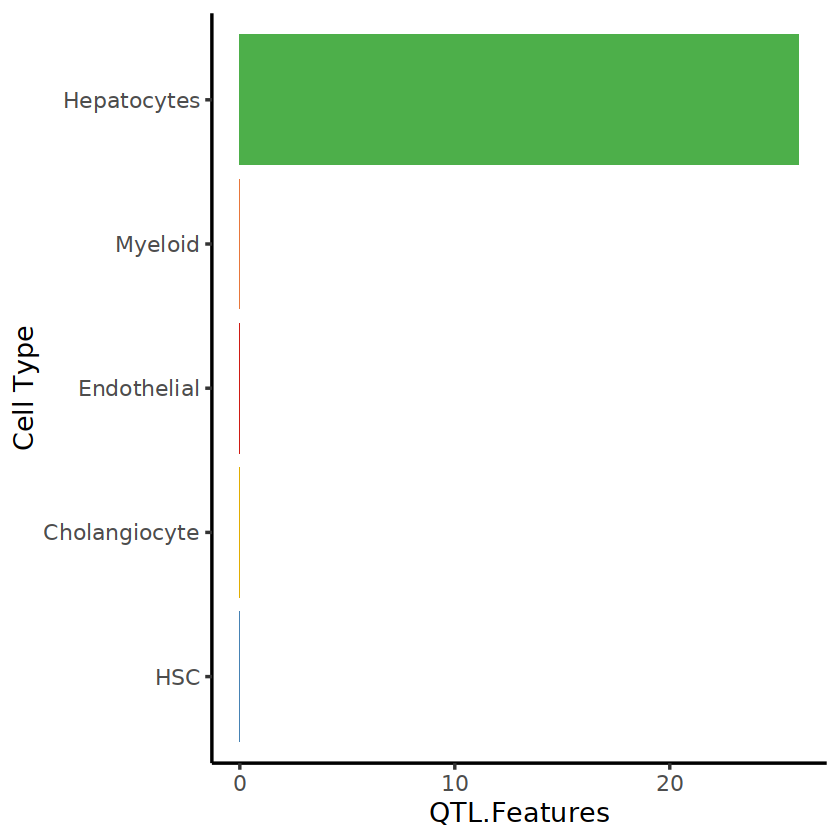

In [24]:
ggplot(summary.df, aes(y=cell, x=features.sig, fill=cell)) + geom_col() + 
    scale_fill_manual(values=celltype_colors) + theme_classic(base_size=16) + 
    labs(fill='Cell Type', x='QTL.Features', y='Cell Type') + theme(legend.position="none")

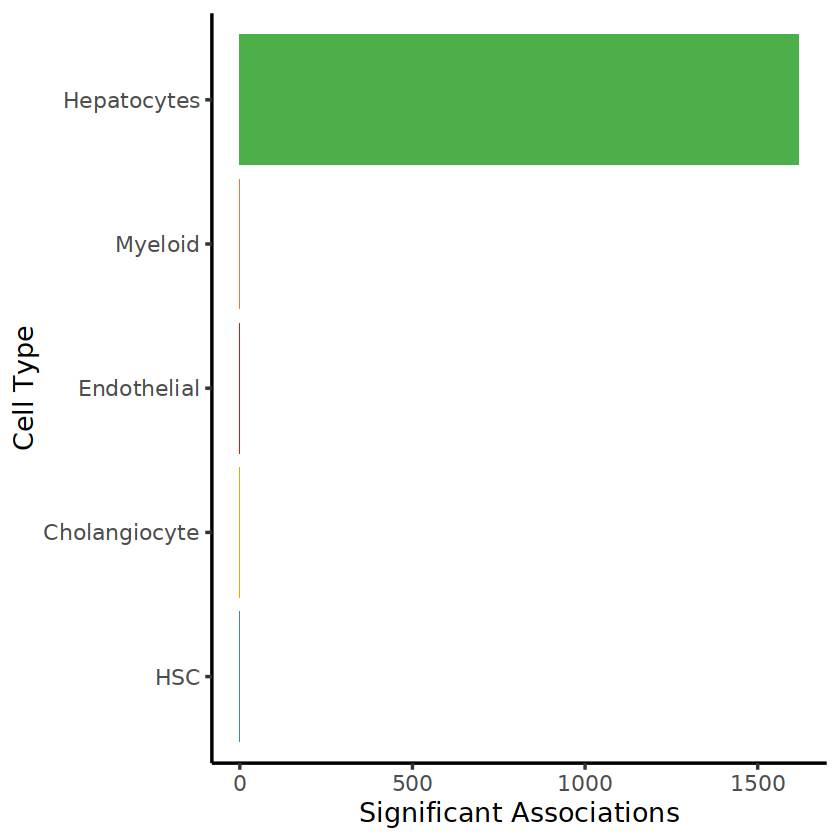

In [25]:
ggplot(summary.df, aes(y=cell, x=tests.sig, fill=cell)) + geom_col() + 
    scale_fill_manual(values=celltype_colors) + theme_classic(base_size=16) + 
    labs(fill='Cell Type', x='Significant Associations', y='Cell Type') + theme(legend.position="none")